In [60]:
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score


In [61]:
df=pd.read_csv("Titanic-Dataset.csv")

In [62]:
df.columns.tolist()

['PassengerId',
 'Survived',
 'Pclass',
 'Name',
 'Sex',
 'Age',
 'SibSp',
 'Parch',
 'Ticket',
 'Fare',
 'Cabin',
 'Embarked']

In [63]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [64]:
df.shape

(891, 12)

In [65]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [66]:
dt=df.copy()
dt.drop(columns=['PassengerId','Ticket'],inplace=True)

In [67]:
dt.columns=[c.strip() for c in dt.columns]
dt.head(3)

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,7.2500,NaN,S
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,71.2833,C85,C
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,7.9250,NaN,S


In [68]:
dt['Pclass'] = dt['Pclass'].astype('category')
dt['Survived'] = dt['Survived'].astype('category')
dt.dtypes[['Pclass','Survived']]

Pclass      category
Survived    category
dtype: object

In [69]:
dt.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,7.2500,NaN,S
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,71.2833,C85,C
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,7.9250,NaN,S
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,53.1000,C123,S
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,8.0500,NaN,S


In [70]:
dt.isnull().sum().sort_values(ascending=False)

Cabin       687
Age         177
Embarked      2
Survived      0
Pclass        0
Name          0
SibSp         0
Sex           0
Fare          0
Parch         0
dtype: int64

In [71]:
dt['Name_clean']=(
    dt['Name']
    .str.strip()
    .str.lower()
    .str.replace(r'[^a-z ,]','',regex=True)
)

In [72]:
dt['Title'] = dt['Name'].apply(lambda x: x.split(",")[1].split(".")[0].strip())
dt['Title'].value_counts().head(10)

Title
Mr        517
Miss      182
Mrs       125
Master     40
Dr          7
Rev         6
Major       2
Mlle        2
Col         2
Don         1
Name: count, dtype: int64

In [73]:
dt['Age'].fillna(dt['Age'].median())
dt['Embarked'].fillna(dt['Embarked'].mode()[0])


0      S
1      C
2      S
3      S
4      S
      ..
886    S
887    S
888    S
889    C
890    Q
Name: Embarked, Length: 891, dtype: str

In [74]:
# Drop the cabin column safely nearly 80%emptyh
dt.drop(columns=['Cabin'], inplace=True)


In [75]:
dt.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked,Name_clean,Title
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,7.2500,S,"braund, mr owen harris",Mr
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,71.2833,C,"cumings, mrs john bradley florence briggs thayer",Mrs
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,7.9250,S,"heikkinen, miss laina",Miss
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,53.1000,S,"futrelle, mrs jacques heath lily may peel",Mrs
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,8.0500,S,"allen, mr william henry",Mr


In [76]:
dt["FamilySize"] = dt["SibSp"] + dt["Parch"] + 1

In [77]:
dt["IsAlone"] = (dt["FamilySize"] == 1).astype(int)

In [78]:
df["Survived"].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [79]:
dt.dtypes

Survived      category
Pclass        category
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Fare           float64
Embarked           str
Name_clean         str
Title              str
FamilySize       int64
IsAlone          int64
dtype: object

In [80]:
dt.select_dtypes(include="object").columns

C:\Users\Hp\AppData\Local\Temp\ipykernel_15636\1169955623.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  dt.select_dtypes(include="object").columns


Index(['Name', 'Sex', 'Embarked', 'Name_clean', 'Title'], dtype='str')

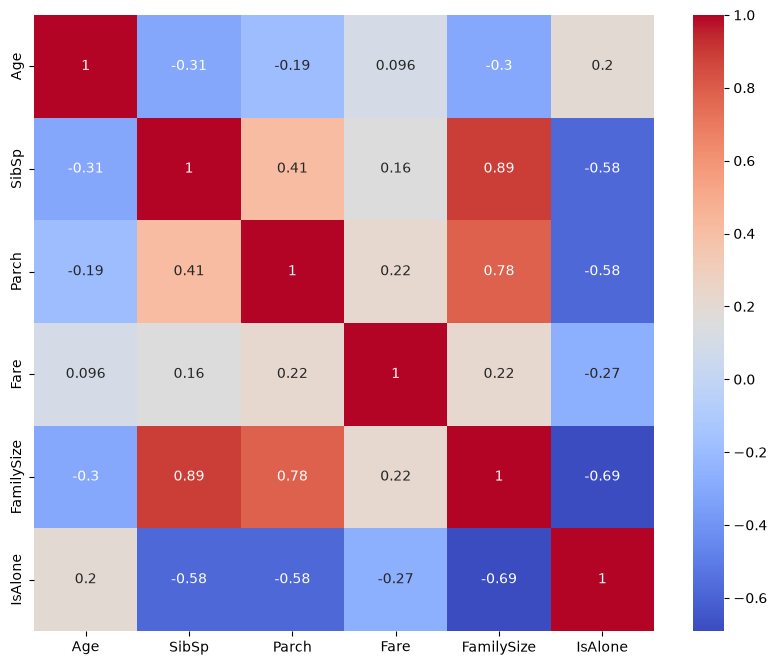

In [81]:
plt.figure(figsize=(10,8))
sns.heatmap(dt.select_dtypes(include="number").corr(), annot=True, cmap="coolwarm")
plt.show()

In [82]:
dt

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked,Name_clean,Title,FamilySize,IsAlone
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,7.2500,S,"braund, mr owen harris",Mr,2,0
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,71.2833,C,"cumings, mrs john bradley florence briggs thayer",Mrs,2,0
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,7.9250,S,"heikkinen, miss laina",Miss,1,1
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,53.1000,S,"futrelle, mrs jacques heath lily may peel",Mrs,2,0
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,8.0500,S,"allen, mr william henry",Mr,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,13.0000,S,"montvila, rev juozas",Rev,1,1
887,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,30.0000,S,"graham, miss margaret edith",Miss,1,1
888,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,23.4500,S,"johnston, miss catherine helen carrie",Miss,4,0
889,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,30.0000,C,"behr, mr karl howell",Mr,1,1


In [83]:
dt.drop(columns=['SibSp','Parch'],inplace=True)

In [84]:
dt.head()

,Survived,Pclass,Name,Sex,Age,Fare,Embarked,Name_clean,Title,FamilySize,IsAlone
0,0,3,"Braund, Mr. Owen Harris",male,22.0,7.2500,S,"braund, mr owen harris",Mr,2,0
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,71.2833,C,"cumings, mrs john bradley florence briggs thayer",Mrs,2,0
2,1,3,"Heikkinen, Miss. Laina",female,26.0,7.9250,S,"heikkinen, miss laina",Miss,1,1
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,53.1000,S,"futrelle, mrs jacques heath lily may peel",Mrs,2,0
4,0,3,"Allen, Mr. William Henry",male,35.0,8.0500,S,"allen, mr william henry",Mr,1,1


In [97]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

dt["Sex"] = le.fit_transform(dt["Sex"])
dt["Embarked"] = le.fit_transform(dt["Embarked"])
dt["Title"] = le.fit_transform(dt["Title"])
dt['Age'].fillna(dt['Age'].median())

0      22.0
1      38.0
2      26.0
3      35.0
4      35.0
       ... 
886    27.0
887    19.0
888    28.0
889    26.0
890    32.0
Name: Age, Length: 891, dtype: float64

In [103]:
known_age = dt[dt["Age"].notna()]
unknown_age = dt[dt["Age"].isna()]

In [104]:
y = known_age["Age"]
X = known_age.drop("Age", axis=1)
X = X.drop(columns=["Name", "Name_clean"], errors="ignore")

In [105]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [106]:
X_train

,Survived,Pclass,Sex,Fare,Embarked,Title,FamilySize,IsAlone
328,1,3,0,20.5250,2,12,3,0
73,0,3,1,14.4542,0,11,2,0
253,0,3,1,16.1000,2,11,2,0
719,0,3,1,7.7750,2,11,1,1
666,0,2,1,13.0000,2,11,1,1
...,...,...,...,...,...,...,...,...
92,0,1,1,61.1750,2,11,2,0
134,0,2,1,13.0000,2,11,1,1
337,1,1,0,134.5000,0,8,1,1
548,0,3,1,20.5250,2,11,3,0


In [107]:
y_train

328    31.0
73     26.0
253    30.0
719    33.0
666    25.0
       ... 
92     46.0
134    25.0
337    41.0
548    33.0
130    33.0
Name: Age, Length: 571, dtype: float64

In [117]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=2,
    random_state=42
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of 

In [118]:
y_pred=rf.predict(X_test)

In [119]:
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))


MAE: 8.373206060016487
RMSE: 10.649677069118214
R2 Score: 0.3882791152966497


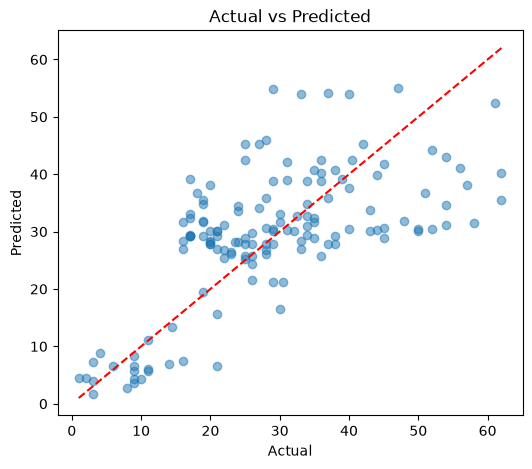

In [120]:
plt.figure(figsize=(6,5))
plt.scatter(y_test, y_pred, alpha=0.5)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, 'r--')
plt.xlabel('Actual'); plt.ylabel('Predicted'); plt.title('Actual vs Predicted')
plt.show()


In [121]:
train_score = rf.score(X_train, y_train)
test_score = rf.score(X_test, y_test)

print(f"Training Score : {train_score:.4f}")
print(f"Testing Score  : {test_score:.4f}")

Training Score : 0.6594
Testing Score  : 0.3883
